#hangi durumlarda kullanılır
sınıflandırma:bu projede olduğu gibibir insanın tümörünün iyi huylu mu yoksa kötü huylu mu olduğunu tahmin etmek gibi problemlerde
regresyon:ev fiyatları veya borsa tahmini gibi sürekli sayısal  bir değerin tahmin edilmesinde
görüntü ve doğal dil işleme:daha derin mimariler kullanarak fotoğrafları tanımak veya metinleri analiz etmek

#hangi durumlarda kullanılır
sınıflandırma:bu projede olduğu gibibir insanın tümörünün iyi huylu mu yoksa kötü huylu mu olduğunu tahmin etmek gibi problemlerde
regresyon:ev fiyatları veya borsa tahmini gibi sürekli sayısal  bir değerin tahmin edilmesinde
görüntü ve doğal dil işleme:daha derin mimariler kullanarak fotoğrafları tanımak veya metinleri analiz etmek gerektiğinde

#modelimi kurarken hangi parametleri belirledim ve test ettim
YSAnın en kritik aşaması hiperparametre optimizasyonu modelini kurarken şu parametreleri belirledim ve test ettim
gizli katmanlar ve nöron sayısı:ağın karmaşıklığını belirler modelimde(64,32)yani ilk katmanda 64,ikinci katmanda 32 nöron olan bir yapı kullandım
aktivasyon fonksiyonu: nöronlara doğrusal olmayan bir özellik katmak için projede ReLU (Rectified Linear Unit) fonksiyonunu tercih ettim
Bu ağın daha hızlı ve performanslı öğrenmesini sağladı
optimizasyon algoritması: ağırlıkları güncellemek ve hatayı minimize etmek için günümüzde en çok tercih edilen Adam optimizasyonunu kullandım
maksimum iterasyon: modelin tüm veri setini kaç kez göreceğini belirler
Öğrenmenin tam gerçekleşmesi için bu değeri 300 olarak ayarladım

#çıktıları nelerdir?
Modelimin çıktısı çözdüğüm probleme göre değişiyor Ben bu projede bir sınıflandırma problemi çözdüğüm için çıktım sınıf etiketleri
(0:kötü huylu,1:iyi huylu) ve bu sınıflara ait olasılık değerleridir

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32),
activation='relu',
solver='adam',
max_iter=300,
random_state=42)

In [11]:
mlp_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [12]:
y_pred = mlp_model.predict(X_test_scaled)

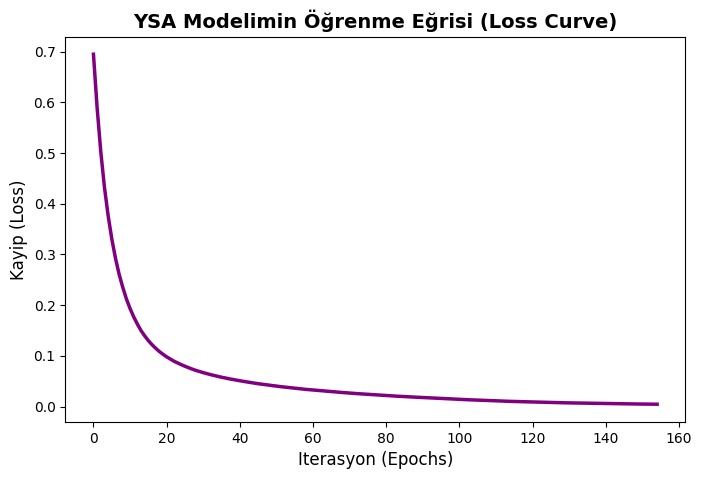

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_, color='purple', linewidth=2.5)
plt.title("YSA Modelimin Öğrenme Eğrisi (Loss Curve)", fontsize=14, fontweight='bold')
plt.xlabel("Iterasyon (Epochs)", fontsize=12)
plt.ylabel("Kayip (Loss)", fontsize=12)
plt.show()

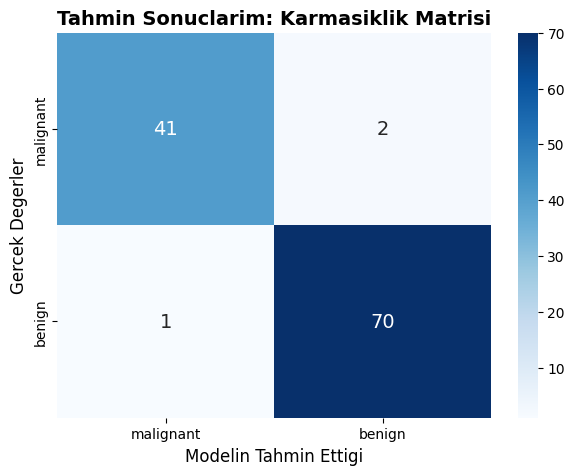

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=data.target_names,
yticklabels=data.target_names,
annot_kws={"size": 14})
plt.title("Tahmin Sonuclarim: Karmasiklik Matrisi", fontsize=14, fontweight='bold')
plt.xlabel("Modelin Tahmin Ettigi", fontsize=12)
plt.ylabel("Gercek Degerler", fontsize=12)
plt.show()

In [21]:
y_prob = mlp_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

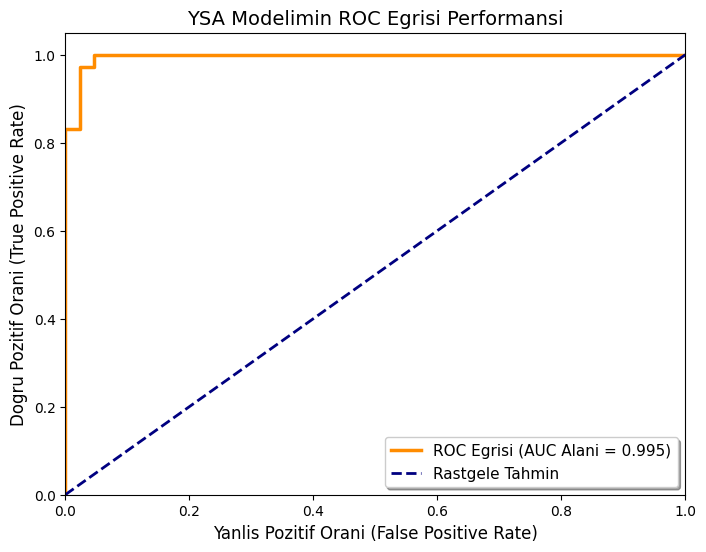

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Egrisi (AUC Alani = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlis Pozitif Orani (False Positive Rate)', fontsize=12)
plt.ylabel('Dogru Pozitif Orani (True Positive Rate)', fontsize=12)
plt.title('YSA Modelimin ROC Egrisi Performansi', fontsize=14)
plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=11)
plt.show()

grafik 1:ağın gerçekten öğrenip öğrenmediğini  matplotlip kullanarak kayıp loss eğrisini çizdirdim grafiğe baktığımda iterasyonlar
 arttıkça hata oranının istikrarlı bir şekilde düştüğünü ve sıfıra yaklaştığını görüyorum
  model ezberlemeden parametreleri güzel bir şekilde optimize ediyor

grafik 2:seaborn ütüphanesini kullanarak bir karmaşıklık matrisi  oluşturdum ısı haritasına ) baktığımda köşegen üzerindeki koyu mavi renkli hücreler modelimin doğru tahmin ettiği hasta sayılarını gösteriyor modelimin hata payının (yanlış pozitif/negatif) oldukça düşük olduğunu gözlemledim

modelimin sınıfları birbirinden ne kadar iyi ayırabildiğini görmek için bir ROC eğrisi çizdirdim Eğrinin sol üst köşeye ne kadar yakın olduğu modelin başarısını gösterir hesapladığım eğri altında kalan alande ğeri 1.0'a çok yakın çıktı bu grafik bana şunu kanıtlıyor kurduğum yapay sinir ağı modeli rastgele tahmin yapmak yerine kanserli ve kansersiz hücrelerin arasındaki o ince matematiksel örüntüyü neredeyse kusursuz bir şekilde öğrenmiş